In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import json

In [2]:
studies_df = pd.DataFrame(json.load(open('../data/study_table.json', 'r')))

valid_study_values = studies_df.study_name.unique().tolist()

studies_df

,study_id,study_name,study_description,entity_connection_table,study_ELN
0,1,hepatocyte (pilot),Pilot study to evaluate effects of oxybutyne-9...,hepatocyte_pilot_entity_connection,(1) ELN743291 - RNA-seq Data Generation; (2) E...
1,2,hepatocyte (signature screen),Signature screen to evaluate effects of oxybut...,hepatocyte_signature_screen_entity_connection,(1) ELN302847 - RNA-seq Data Generation; (2) E...
2,3,astrocyte (pilot),Pilot study to evaluate effects of randomomab ...,astrocyte_pilot_entity_connection,(1) ELN093471 - 10X Chromium Data Generation; ...
3,4,astrocyte (signature screen),Signature screen to evaluate effects of random...,astrocyte_signature_screen_entity_connection,(1) ELN410856 - 10X Chromium Data Generation; ...
4,5,microglia (pilot),Pilot study to evaluate effects of florbinasta...,microglia_pilot_entity_connection,(1) ELN047293 - snRNA-seq Data Generation; (2)...
5,6,microglia (signature screen),Signature screen to evaluate effects of florbi...,microglia_signature_screen_entity_connection,(1) ELN784502 - snRNA-seq Data Generation; (2)...
6,7,cardiomyocyte (pilot),Pilot study to evaluate effects of glompezumab...,cardiomyocyte_pilot_entity_connection,(1) ELN371640 - Bulk RNA-seq Data Generation; ...
7,8,cardiomyocyte (signature screen),Signature screen to evaluate effects of glompe...,cardiomyocyte_signature_screen_entity_connection,(1) ELN924517 - 10X Chromium Data Generation; ...
8,9,pancreatic beta cell (pilot),Pilot study to evaluate effects of trocavapine...,pancreatic_beta_cell_pilot_entity_connection,(1) ELN073618 - SMART-seq Data Generation; (2)...
9,10,pancreatic beta cell (signature screen),Signature screen to evaluate effects of trocav...,pancreatic_beta_cell_signature_screen_entity_c...,(1) ELN347801 - snRNA-seq Data Generation; (2)...


In [3]:
uniprot_id_to_go = pd.DataFrame(json.load(open('../data/uniprot_id_to_go.json', 'r')))

uniprot_id_to_go = uniprot_id_to_go.loc[uniprot_id_to_go.uniprot_id.str.len() == 6]

uniprot_id_to_go

,uniprot_id,go_desc
0,Q969Q1,zinc ion binding
1,P16455,catalytic activity
2,P16455,DNA repair
3,P16455,methylated-DNA-[protein]-cysteine S-methyltran...
4,Q9H6E5,RNA binding
...,...,...
39895,Q8TAG9,intracellular protein transport
39896,Q8TAG9,vesicle tethering involved in exocytosis
39897,Q96RQ9,oxidoreductase activity
39898,O75808,calcium-dependent cysteine-type endopeptidase ...


In [4]:
gene_mapping_df = pd.DataFrame(json.load(open('../data/gene_mapping.json', 'r')))

uniprot_to_ensembl_mapping = dict(zip(gene_mapping_df.uniprot_id, gene_mapping_df.ensembl_gene_id))
uniprot_to_gene_symbol_mapping = dict(zip(gene_mapping_df.uniprot_id, gene_mapping_df.gene_symbol))

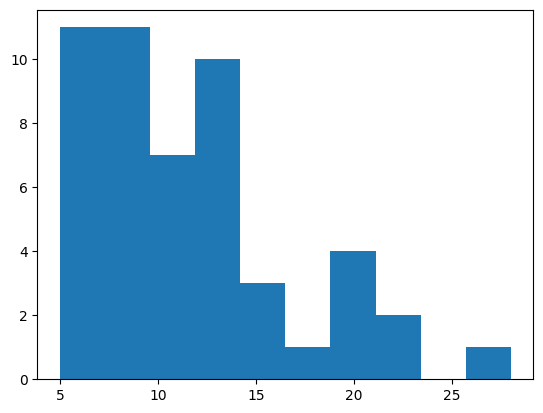

array([ 9,  7,  6, 14,  8, 10, 15,  9,  5, 10, 20,  8, 10, 14,  8, 12,  8,
        7,  8, 10, 28, 12, 13, 23, 19, 13,  9, 16, 10, 20, 12, 13,  5,  5,
        5, 12, 15, 10, 12,  8,  6,  8,  8,  7, 18, 11,  5,  7, 23, 19])

In [34]:
N_GENE_SETS = 50

np.random.seed(1)

distribution_of_gene_set_sizes = (np.random.poisson(lam=3, size=N_GENE_SETS) * np.random.uniform(1, 4, size=N_GENE_SETS) + 5).astype(int)

plt.hist(distribution_of_gene_set_sizes)
plt.show()

distribution_of_gene_set_sizes


In [35]:
N_GENES_SUBSAMPLED = 5000

uniprot_id_to_go.sample(N_GENES_SUBSAMPLED, random_state=1)

,uniprot_id,go_desc
7944,Q9NZR2,calcium ion binding
29428,Q9BZP6,"hydrolase activity, hydrolyzing O-glycosyl com..."
38154,Q5SWL8,negative regulation of cell differentiation
4055,Q96LA9,membrane
29447,O95363,nucleotide binding
...,...,...
917,O95185,netrin-activated signaling pathway
4384,O60290,regulation of DNA-templated transcription
12092,P47989,oxidoreductase activity
13653,Q6IQ26,small GTPase binding


In [36]:
np.random.seed(None)

gene_sets_dfs = []

for i, gene_set_size in enumerate(distribution_of_gene_set_sizes):
    gene_set_df = uniprot_id_to_go.sample(N_GENES_SUBSAMPLED, random_state=1).sample(gene_set_size)
    gene_set_df["modulated_circuit"] = f"gene_set_{ i+1 }"
    
    gene_sets_dfs.append(gene_set_df)

gene_sets_df = pd.concat(gene_sets_dfs)
gene_sets_df["ensembl_gene_id"] = gene_sets_df.uniprot_id.map(uniprot_to_ensembl_mapping)

gene_sets_df = gene_sets_df.dropna().groupby("modulated_circuit").agg({"ensembl_gene_id": list}).reset_index()

gene_sets_df

,modulated_circuit,ensembl_gene_id
0,gene_set_1,"[ENSG00000139880, ENSG00000138613, ENSG0000029..."
1,gene_set_10,"[ENSG00000129159, ENSG00000187790, ENSG0000029..."
2,gene_set_11,"[ENSG00000196109, ENSG00000244462, ENSG0000014..."
3,gene_set_12,"[ENSG00000197506, ENSG00000197111, ENSG0000017..."
4,gene_set_13,"[ENSG00000070526, ENSG00000129315, ENSG0000028..."
5,gene_set_14,"[ENSG00000184945, ENSG00000180979, ENSG0000013..."
6,gene_set_15,"[ENSG00000073282, ENSG00000057935, ENSG0000008..."
7,gene_set_16,"[ENSG00000130749, ENSG00000163083, ENSG0000015..."
8,gene_set_17,"[ENSG00000142453, ENSG00000148331, ENSG0000004..."
9,gene_set_18,"[ENSG00000137522, ENSG00000127328, ENSG0000013..."


In [37]:
gene_sets_df.to_json("../data/gene_sets.json", orient="records", indent=1)

---

### Building "study : upstream_regulator_ensembl_id : go_term_associated_with_circuit" triples

In [38]:
valid_subset_of_go_terms = uniprot_id_to_go.go_desc.drop_duplicates().sample(100).values.tolist()

In [50]:
np.random.seed(None)

upstream_regulators_dfs = []

for study in valid_study_values:
    n_upstream_regulators = np.random.randint(100, 400)

    upstream_regulators = uniprot_id_to_go.sample(N_GENES_SUBSAMPLED, random_state=1).sample(n_upstream_regulators).dropna()

    upstream_regulators["ensembl_gene_id"] = upstream_regulators.uniprot_id.map(uniprot_to_ensembl_mapping)
    upstream_regulators["study_name"]      = study

    upstream_regulators = upstream_regulators[["study_name", "ensembl_gene_id"]].rename(columns = {"ensembl_gene_id": "upstream_regulator_ensembl_gene_id"})

    upstream_regulators["go_term_associated_with_circuit"] = [
        np.random.choice(valid_subset_of_go_terms, np.random.randint(1, 4), replace=False).tolist()
        for _ in range(len(upstream_regulators))
    ]

    upstream_regulators = upstream_regulators.explode("go_term_associated_with_circuit").reset_index(drop=True)

    upstream_regulators["modulated_circuit_list"] = [
        np.random.choice(gene_sets_df.modulated_circuit, np.random.randint(1, 4), replace=False).tolist()
        for _ in range(len(upstream_regulators))
    ]
    upstream_regulators = upstream_regulators.explode("modulated_circuit_list").reset_index(drop=True)

    upstream_regulators_dfs.append(upstream_regulators)

upstream_regulators = pd.concat(upstream_regulators_dfs).reset_index(drop=True)

upstream_regulators


,study_name,upstream_regulator_ensembl_gene_id,go_term_associated_with_circuit,modulated_circuit_list
0,hepatocyte (pilot),ENSG00000062485,NuA4 histone acetyltransferase complex,gene_set_28
1,hepatocyte (pilot),ENSG00000062485,NuA4 histone acetyltransferase complex,gene_set_45
2,hepatocyte (pilot),ENSG00000062485,NuA4 histone acetyltransferase complex,gene_set_3
3,hepatocyte (pilot),ENSG00000062485,regulation of mitotic cell cycle spindle assem...,gene_set_31
4,hepatocyte (pilot),ENSG00000062485,regulation of mitotic cell cycle spindle assem...,gene_set_49
...,...,...,...,...
11755,proximal tubule cell (signature screen),ENSG00000165804,intein-mediated protein splicing,gene_set_22
11756,proximal tubule cell (signature screen),ENSG00000165804,intein-mediated protein splicing,gene_set_50
11757,proximal tubule cell (signature screen),ENSG00000165804,intein-mediated protein splicing,gene_set_48
11758,proximal tubule cell (signature screen),ENSG00000165804,Golgi transport complex,gene_set_22


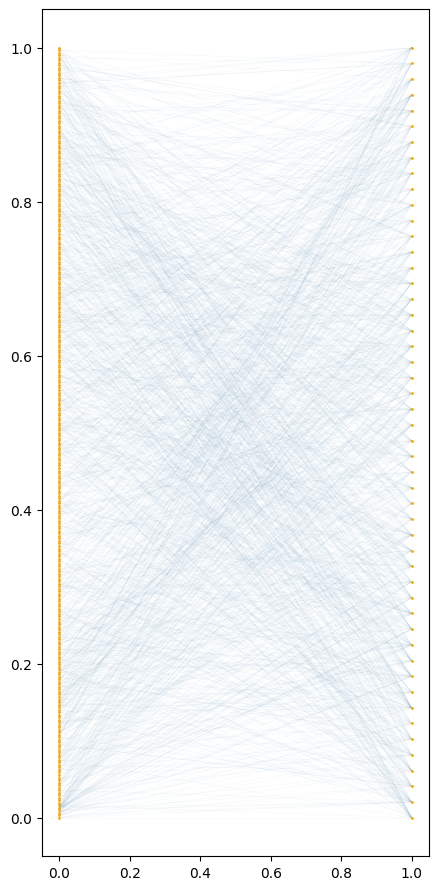

In [ ]:
"""
Links between upstream_regulator_ensembl_gene_id and modulated_circuit_list for a single study look suitably many-to-many. 
"""

diagnostics = upstream_regulators.loc[
    upstream_regulators.study_name == upstream_regulators.study_name.sample(1).values[0],
    ["upstream_regulator_ensembl_gene_id", "modulated_circuit_list"]].copy()

reg_ids   = {v: i for i, v in enumerate(diagnostics["upstream_regulator_ensembl_gene_id"].unique())}
circ_ids  = {v: i for i, v in enumerate(diagnostics["modulated_circuit_list"].unique())}

diagnostics["reg_id"]  = diagnostics["upstream_regulator_ensembl_gene_id"].map(reg_ids)
diagnostics["circ_id"] = diagnostics["modulated_circuit_list"].map(circ_ids)

fig, ax = plt.subplots(figsize=(5, 11))

n_reg  = len(reg_ids)
n_circ = len(circ_ids)

for _, row in diagnostics.iterrows():
    y_left  = row["reg_id"]  / max(n_reg  - 1, 1)
    y_right = row["circ_id"] / max(n_circ - 1, 1)
    ax.plot([0, 1], [y_left, y_right], color="steelblue", alpha=0.05, linewidth=0.5)

ax.scatter([0] * n_reg,  [i / max(n_reg  - 1, 1) for i in range(n_reg)],  s=1, color="orange", zorder=3)
ax.scatter([1] * n_circ, [i / max(n_circ - 1, 1) for i in range(n_circ)], s=1, color="orange", zorder=3)

plt.show()

In [55]:
upstream_regulators.to_json("../data/upstream_regulators.json", orient="records", indent=1)